In [1]:
import os
import pandas as pd
import numpy as np

from keras.models import load_model                                             # Model loading Method
from sklearn.metrics import roc_auc_score,accuracy_score, cohen_kappa_score     # Metrics
import numpy as np
from skimage import io
from skimage import feature, color
from skimage.filters import roberts, sobel, scharr, prewitt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,\
                            auc, \
                            precision_score, \
                            recall_score, \
                            f1_score

2025-04-09 10:04:05.449238: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-09 10:04:05.500440: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-09 10:04:05.502713: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-09 10:04:13.475639: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
edge_based_weights_dir = '/external/model-weights/EDGE-Based-CNN'

In [3]:
all_files = os.listdir(edge_based_weights_dir)
substrings = ['canny', 
              'sobel','roberts']
weights_dirs = [
    file for file in all_files if any(sub in file for sub in substrings) and file.endswith('.py') !=True and file.endswith('results') ==True
]
weights_dirs

['alexnet_canny_results',
 'alexnet_roberts_results',
 'alexnet_sobel_results',
 'inceptionv3_canny_results',
 'inceptionv3_roberts_results',
 'inceptionv3_sobel_results',
 'resnet50_canny_results',
 'resnet50_roberts_results',
 'resnet50_sobel_results',
 'vgg16_canny_results',
 'vgg16_roberts_results',
 'vgg16_sobel_results']

In [16]:
# cwd = os.getcwd()
model_to_weights_path = dict()
for model in weights_dirs:
    model_path = os.path.join(edge_based_weights_dir,model)
    model_to_weights_path[model] = model_path

In [17]:
model_to_weights_path

{'alexnet_canny_results': '/external/model-weights/EDGE-Based-CNN/alexnet_canny_results',
 'alexnet_roberts_results': '/external/model-weights/EDGE-Based-CNN/alexnet_roberts_results',
 'alexnet_sobel_results': '/external/model-weights/EDGE-Based-CNN/alexnet_sobel_results',
 'inceptionv3_canny_results': '/external/model-weights/EDGE-Based-CNN/inceptionv3_canny_results',
 'inceptionv3_roberts_results': '/external/model-weights/EDGE-Based-CNN/inceptionv3_roberts_results',
 'inceptionv3_sobel_results': '/external/model-weights/EDGE-Based-CNN/inceptionv3_sobel_results',
 'resnet50_canny_results': '/external/model-weights/EDGE-Based-CNN/resnet50_canny_results',
 'resnet50_roberts_results': '/external/model-weights/EDGE-Based-CNN/resnet50_roberts_results',
 'resnet50_sobel_results': '/external/model-weights/EDGE-Based-CNN/resnet50_sobel_results',
 'vgg16_canny_results': '/external/model-weights/EDGE-Based-CNN/vgg16_canny_results',
 'vgg16_roberts_results': '/external/model-weights/EDGE-Based-

In [18]:
# resnet50_roberts_results= '/home/acdsd/Desktop/Hydrogen Fairy Circles/vgg16_sobel_results'
# weights = [file for file in os.listdir(resnet50_roberts_results) if file.endswith('.tf')][0]

# resnet50_robert_weights_path = os.path.join(resnet50_roberts_results,weights)
# resnet50_robert_model = load_model(resnet50_robert_weights_path)
# resnet50_robert_model

In [19]:
# val_loss,val_acc = resnet50_robert_model.evaluate(val_generator)
# val_loss,val_acc

## AUC ROC PLotting Function

In [20]:
# def plot_roc_auc_models(y_val_true, models_prob,image_name='AUC-ROC-COMPARISON.png'):
#     plt.figure(figsize=(12,6),facecolor='w')
#     lw = 2
#     colors = ['darkorange', 'blue', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan','wheat','turquoise']
#     # print(len(models_prob))
#     for i,model_model_prob in enumerate(models_prob.items()):
#         model = model_model_prob[0]
#         model_prob = model_model_prob[1]
#         # Calculate ROC curve
#         fpr, tpr, _ = roc_curve(y_val_true, model_prob)
        
#         # Calculate AUC
#         roc_auc = auc(fpr, tpr)
        
#         model_name_list = model.split('_')[:2]
#         model_name_list = [word.capitalize() for word in model_name_list]
#         model = ' '.join(model_name_list)
        
#         # Plot ROC curve
#         plt.plot(fpr, tpr, color=colors[i % len(colors)],linestyle='--',
#                  lw=lw, label=f'{model} ROC curve (area = {roc_auc:.2f})')
    
#     plt.plot([0, 1], [0, 1], color = 'navy', lw=lw, linestyle='-'
#             )
#     plt.xlim([0.0, 1.0])
#     plt.ylim([0.0, 1.05])
#     plt.xlabel('False Positive Rate')
#     plt.ylabel('True Positive Rate')
#     plt.title('Receiver Operating Characteristic Curve')
#     plt.legend(loc="lower right",fontsize='small')
#     plt.savefig(image_name,dpi=300)
#     plt.show()
def plot_roc_auc_models(y_val_true, models_prob, model_names, image_name='AUC-ROC-COMPARISON.png'):
    plt.figure(figsize=(12,6),facecolor='w')
    ax = plt.gca()  # Get current axes
    ax.set_facecolor('white')  # Set axes facecolor to white

    lw = 2
    colors = ['darkorange', 'blue', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']
    
    for i, model_prob in enumerate(models_prob):
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_val_true, model_prob)
        
        # Calculate AUC
        roc_auc = auc(fpr, tpr)
        
        # Plot ROC curve
        plt.plot(fpr, tpr, color=colors[i % len(colors)], linestyle='--',
                 lw=lw, label=f'{model_names[i]} ROC curve (area = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], color='navy', lw=lw)  # Plot diagonal line
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic Curve')
    plt.legend(loc="lower right")
    plt.savefig(image_name, dpi=300, facecolor='w', bbox_inches='tight')  # Save with white background
    plt.show()


### **LOADING TEST SET**

In [21]:
# # Set the image size and batch size
# image_size = (224, 224)  # Inception V3 input size
# batch_size = 32
# val_dir = os.path.abspath('./FC DATASET/Validation set')

In [22]:
# Path to dataset
dataset_dir = '/data'

# seed for reproducibility
seed = 42

# Set the image size and batch size
image_size = (224, 224)  # AlexNet input size
batch_size = 32

# Prepare data using ImageDataGenerator with validation split
datagen = ImageDataGenerator(rescale=1.0/255.0, validation_split=0.2)

# Create the validation generator
val_generator = datagen.flow_from_directory(
    dataset_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    seed = seed,
    shuffle=False
)

Found 3006 images belonging to 2 classes.


## Preprocessing Functions

In [23]:
## ----------------------------------------------------------------- Custom preprocessing wrapper function -------------------------------------------------------- #
def preprocessing_wrapper(method='canny'):
    def preprocessing_function(image):
        return perform_edge_detection(image, method=method)
    return preprocessing_function

def perform_edge_detection(image,method):
    image = color.rgb2gray(image)    # Convert to grayscale
    
    if method == 'canny':
        image = feature.canny(image, sigma=0.02).astype(np.float32)
    if method == 'sobel':
        image = sobel(image).astype(np.float32)
    if method == 'roberts':
        image = roberts(image).astype(np.float32)
    if method == 'scharr':
        image = scharr(image).astype(np.float32)
    if method == 'prewitt':
        image = prewitt(image).astype(np.float32)
        
    image = np.expand_dims(image, axis=-1)  # Add channel dimension
    image = np.repeat(image, 3, axis=-1)    # Repeat the single channel to create a 3-channel image
    return image

In [24]:
pwd

'/app/edge-based-cnn'

In [25]:
# import os
# v_fc = os.listdir('/home/acdsd/Desktop/Hydrogen Fairy Circles/FC DATASET/Validation set/FC/')
# for v in v_fc:
#     if v.endswith('.png'):
#         continue
#     print(v)

In [26]:
# for v in val_generator.filenames:
#     if v.endswith('.png'):
#         continue
#     print(v)

## Looping through Models

In [28]:
models_metrics_map = dict()

for cnn_algo,model_path in model_to_weights_path.items():
    
    model_dir_contents = os.listdir(model_to_weights_path[cnn_algo])
    
    weights_file = [file for file in model_dir_contents if file.endswith('.tf')][0]
    
    weights_file_path = os.path.join(model_to_weights_path[cnn_algo],weights_file)
    
    loaded_cnn_model = load_model(weights_file_path)

    model_name_list = cnn_algo.split('_')#[:2]
    method = model_name_list[1]

    ##---------------------------------------------Preprocessing functions----adding respective-edge-detection-method---------------#
    
    # val_datagen = ImageDataGenerator(rescale=1.0/255.0,preprocessing_function=preprocessing_wrapper(method))
    # val_generator = val_datagen.flow_from_directory(
    #     val_dir,
    #     target_size=image_size,
    #     batch_size=batch_size,
    #     class_mode='binary',
    #     shuffle=False
    # )
    
    # Create a custom filter for filenames
    def filter_filenames(filenames, extensions):
        return [filename for filename in filenames if filename.lower().endswith(extensions)]
    
    # Modify the filenames in the generator
    val_generator.filenames = filter_filenames(val_generator.filenames, ('.png',))
    
    ###--------------------------------------------Extracting True Labels------------------------------------------------------
    y_true = np.array(val_generator.classes)

    ###-------------------------------------------Getting-Predictions---------------------------------------------------------#
    y_pred_prob = loaded_cnn_model.predict(val_generator)
    y_pred_label = (y_pred_prob > 0.5).astype(int).flatten()
    
    # Evaluate the model
    # val_loss, val_acc = loaded_cnn_model.evaluate(val_generator)

    ###-------------------------------------------Calculating-Evaluation-Metrics-----------------------------------------------#
    precision = precision_score(y_true, y_pred_label)
    recall = recall_score(y_true, y_pred_label)
    f1 = f1_score(y_true, y_pred_label)
    acc = accuracy_score(y_true, y_pred_label)
    kappa = cohen_kappa_score(y_true, y_pred_label)
    auc_score = roc_auc_score(y_true, y_pred_prob)

    if kappa < 0:
        interpretation = "Less than chance agreement"
    elif 0 <= kappa <= 0.20:
        interpretation = "Slight agreement"
    elif 0.21 <= kappa <= 0.40:
        interpretation = "Fair agreement"
    elif 0.41 <= kappa <= 0.60:
        interpretation = "Moderate agreement"
    elif 0.61 <= kappa <= 0.80:
        interpretation = "Substantial agreement"
    else:
        interpretation = "Almost perfect agreement"

    ###-----------------------------------------Storing-Calculated-Metrics-Model-Wise---------------------------------------------#
    
    temp = dict()
    temp['y_pred_prob'] = y_pred_prob
    temp['y_pred_label'] = y_pred_label

    temp['precision'] = precision
    temp['recall'] = recall
    temp['f1'] = f1
    temp['accuracy_score'] = acc
    temp['cohen_kappa_score'] = kappa
    temp['interpretation'] = interpretation
    temp['roc_auc_score'] = auc_score
    # temp['val_loss']=val_loss


    models_metrics_map[cnn_algo] = temp

    ###--------------------------------------Printing--Performance-----------------------------------------------------------------#
    print(cnn_algo)
    print('\taccuracy_score :',acc)
    print('\tcohen_kappa_score :',kappa)
    print('\tinterpretation :',interpretation)
    print('\troc_auc_score :',auc_score)
    print("\tprecision :", precision)
    print("\trecall :",recall)
    print("\tf1 :",f1)
    
    print()
    
    
    # plot_roc_auc_models(y_val_true, models_prob, model_names)
    # print(f'{model}\n\t',os.path.join(model_to_weights_path[cnn_algo],weights_file))
    # print()
    

94/94 [==============================] - 42s 448ms/step
alexnet_canny_results
	accuracy_score : 0.9767132401862941
	cohen_kappa_score : 0.9534264803725881
	interpretation : Almost perfect agreement
	roc_auc_score : 0.9907946360550135
	precision : 0.9643551523007129
	recall : 0.9900199600798403
	f1 : 0.9770190413657255

94/94 [==============================] - 42s 447ms/step
alexnet_roberts_results
	accuracy_score : 0.9757152361942781
	cohen_kappa_score : 0.9514304723885563
	interpretation : Almost perfect agreement
	roc_auc_score : 0.9924267676667069
	precision : 0.9703947368421053
	recall : 0.9813705921490352
	f1 : 0.9758518028448561

94/94 [==============================] - 42s 448ms/step
alexnet_sobel_results
	accuracy_score : 0.9747172322022621
	cohen_kappa_score : 0.9494344644045243
	interpretation : Almost perfect agreement
	roc_auc_score : 0.9923076889025232
	precision : 0.9672560576293385
	recall : 0.9827012641383899
	f1 : 0.974917491749175

94/94 [=============================

In [29]:
df = pd.DataFrame.from_dict(models_metrics_map)#, orient='columns'
# Set the index
df.index.name = 'CNN'

# Print the DataFrame
df.drop(index=['y_pred_prob','y_pred_label'],inplace=True)
df = df.transpose()
# Sort the DataFrame by column 'a' in ascending order
df_sorted_asc = df.sort_index()
df_sorted_asc

CNN,precision,recall,f1,accuracy_score,cohen_kappa_score,interpretation,roc_auc_score
alexnet_canny_results,0.964355,0.99002,0.977019,0.976713,0.953426,Almost perfect agreement,0.990795
alexnet_roberts_results,0.970395,0.981371,0.975852,0.975715,0.95143,Almost perfect agreement,0.992427
alexnet_sobel_results,0.967256,0.982701,0.974917,0.974717,0.949434,Almost perfect agreement,0.992308
inceptionv3_canny_results,0.972387,0.984032,0.978175,0.978044,0.956088,Almost perfect agreement,0.997143
inceptionv3_roberts_results,0.976959,0.987359,0.982131,0.982036,0.964072,Almost perfect agreement,0.997516
inceptionv3_sobel_results,0.978709,0.978709,0.978709,0.978709,0.957418,Almost perfect agreement,0.996575
resnet50_canny_results,0.966978,0.896208,0.930249,0.932801,0.865602,Almost perfect agreement,0.985074
resnet50_roberts_results,0.967072,0.898869,0.931724,0.934132,0.868263,Almost perfect agreement,0.985181
resnet50_sobel_results,0.967297,0.885562,0.924627,0.927811,0.855622,Almost perfect agreement,0.985055
vgg16_canny_results,0.982883,0.993347,0.988087,0.988024,0.976048,Almost perfect agreement,0.999241


In [31]:
df_sorted_asc.to_csv('EDGE-Based-CNN-Evaluations.csv')

In [33]:
# # Make predictions
# alexnet_y_val_prob = alexnet_model.predict(val_generator)
# resne_y_val_prob = resnet_model.predict(val_generator)
# inception_y_val_prob = inception_model.predict(val_generator)
# vgg_y_val_prob = vgg_model.predict(val_generator)

In [34]:


# models_prob = [alexnet_y_val_prob,inception_y_val_prob,resne_y_val_prob,vgg_y_val_prob]
# model_names = ['AlexNet','InceptionV3','ResNet50','VGG16']
models_prob = []
model_names = []
for cnn_algo,vals in models_metrics_map.items():
    model_names.append(cnn_algo)
    models_prob.append(vals['y_pred_prob'])

In [35]:
# models_prob

In [36]:
model_probs = dict()

for model,val in models_metrics_map.items():
    if 'canny' in model:
        continue
    model_probs[model] = val['y_pred_prob']


In [37]:
model_probs.keys()

dict_keys(['alexnet_roberts_results', 'alexnet_sobel_results', 'inceptionv3_roberts_results', 'inceptionv3_sobel_results', 'resnet50_roberts_results', 'resnet50_sobel_results', 'vgg16_roberts_results', 'vgg16_sobel_results'])

In [40]:
# plot_roc_auc_models(y_val_true, models_prob, model_names, image_name='AUC-ROC-COMPARISON.png'):

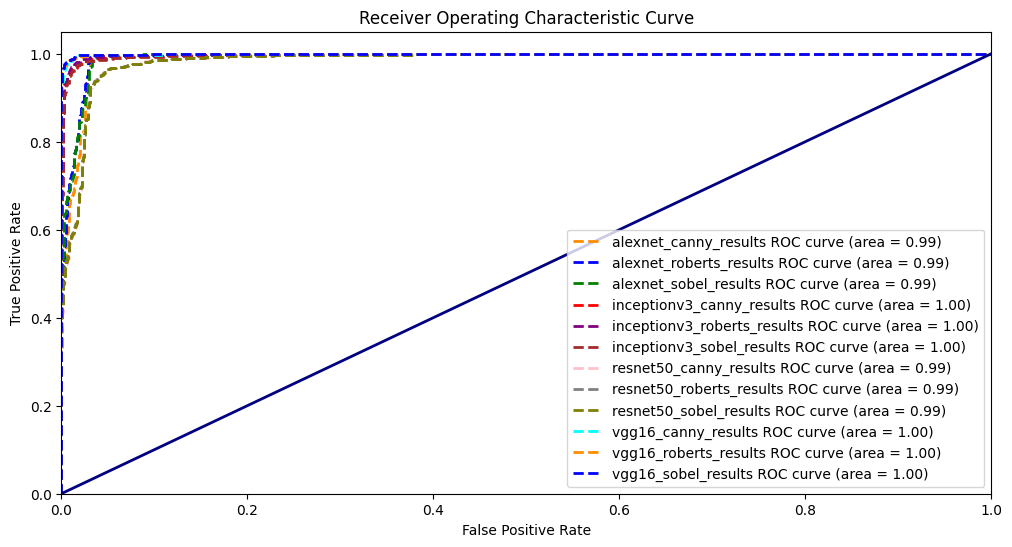

In [39]:
plot_roc_auc_models(y_val_true=y_true, models_prob = models_prob,model_names=model_names,image_name='GRAYSCALE-IMAGE-AUC-ROC-COMPARISON_600_dpi.png')

In [41]:
# Function to remove the last word from a string
def remove_last_word(s):
    return ' '.join(s.split(' ')[:-1])

# Remove the last word from each index value
df_sorted_asc.index = df_sorted_asc.index.str.replace('_', ' ').str.title().map(remove_last_word)

df_sorted_asc

CNN,precision,recall,f1,accuracy_score,cohen_kappa_score,interpretation,roc_auc_score
Alexnet Canny,0.964355,0.99002,0.977019,0.976713,0.953426,Almost perfect agreement,0.990795
Alexnet Roberts,0.970395,0.981371,0.975852,0.975715,0.95143,Almost perfect agreement,0.992427
Alexnet Sobel,0.967256,0.982701,0.974917,0.974717,0.949434,Almost perfect agreement,0.992308
Inceptionv3 Canny,0.972387,0.984032,0.978175,0.978044,0.956088,Almost perfect agreement,0.997143
Inceptionv3 Roberts,0.976959,0.987359,0.982131,0.982036,0.964072,Almost perfect agreement,0.997516
Inceptionv3 Sobel,0.978709,0.978709,0.978709,0.978709,0.957418,Almost perfect agreement,0.996575
Resnet50 Canny,0.966978,0.896208,0.930249,0.932801,0.865602,Almost perfect agreement,0.985074
Resnet50 Roberts,0.967072,0.898869,0.931724,0.934132,0.868263,Almost perfect agreement,0.985181
Resnet50 Sobel,0.967297,0.885562,0.924627,0.927811,0.855622,Almost perfect agreement,0.985055
Vgg16 Canny,0.982883,0.993347,0.988087,0.988024,0.976048,Almost perfect agreement,0.999241


In [20]:
df_sorted_asc.to_csv('EDGE-CNN-MODEL-EVALUATION-METRICS_with_VAL_LOSS.csv')

In [ ]:
for model,val in models_metrics_map.items():
    if 'canny' in model:
        continue
    